In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the data
file_path = '/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons.data'
df = pd.read_csv(file_path)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# Feature information
print("\nData types:")
print(df.dtypes)

# Count unique subjects
print(f"\nNumber of unique subjects: {df['status'].nunique()}")

Dataset shape: (195, 24)

First 5 rows:
             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      R

In [ ]:
# Define features and target
feature_cols = df.columns.difference(['name', 'status'])
X = df[feature_cols]
y = df['status']  # Target variable is 'status'

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)

1. Linear SVM Coefficients
             Feature  Coefficient
11          MDVP:RAP     0.967283
3         Jitter:DDP     0.964330
8     MDVP:Jitter(%)     0.934314
9   MDVP:Jitter(Abs)     0.923866
15               PPE     0.749483
4           MDVP:APQ     0.745471
19       Shimmer:DDA     0.530220
17      Shimmer:APQ3     0.525904
7        MDVP:Fo(Hz)     0.314127
13  MDVP:Shimmer(dB)     0.306667


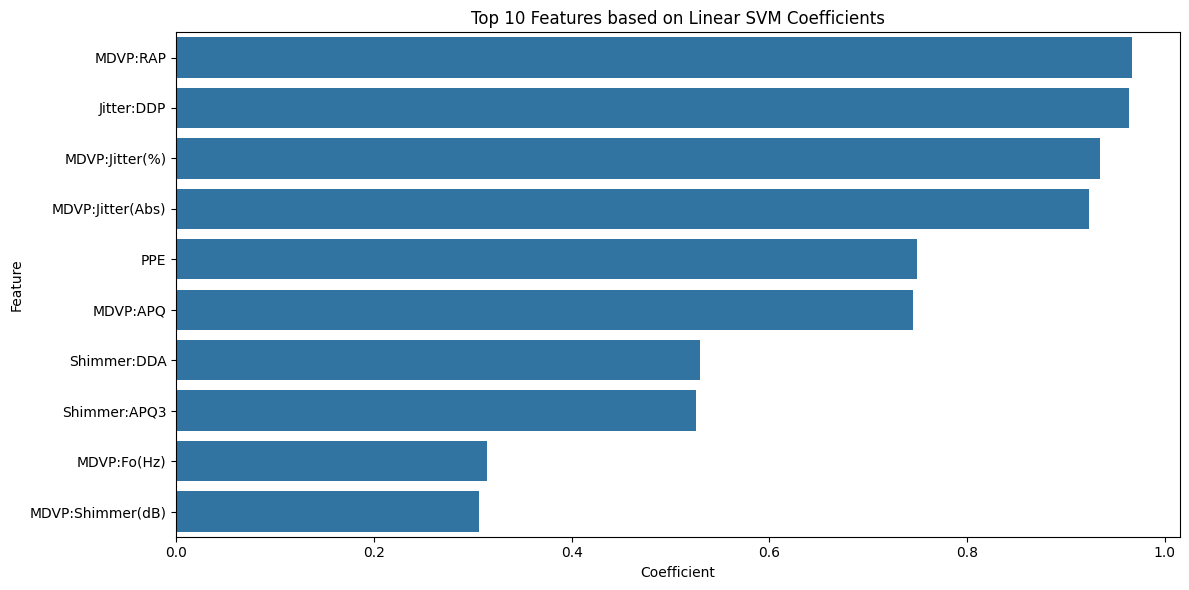


2. Recursive Feature Elimination with SVM
             Feature  Ranking
0                 D2        1
3         Jitter:DDP        1
7        MDVP:Fo(Hz)        1
4           MDVP:APQ        1
11          MDVP:RAP        1
10          MDVP:PPQ        1
9   MDVP:Jitter(Abs)        1
8     MDVP:Jitter(%)        1
15               PPE        1
19       Shimmer:DDA        1

3. L1-based Feature Selection
    Feature  Selected
20  spread1         1

4. Univariate Feature Selection with ANOVA F-value
         Feature    F-Score       P-value
20       spread1  73.263142  1.081407e-14
15           PPE  63.327413  3.548023e-13
21       spread2  40.337602  2.285936e-09
7    MDVP:Fo(Hz)  28.878435  2.799551e-07
2            HNR  27.195298  5.841568e-07
6   MDVP:Flo(Hz)  26.144013  9.286905e-07
12  MDVP:Shimmer  25.368770  1.309984e-06
4       MDVP:APQ  24.585941  1.857520e-06
0             D2  24.583667  1.859411e-06
18  Shimmer:APQ5  23.643784  2.835130e-06

5. Principal Component Analysis (PCA)

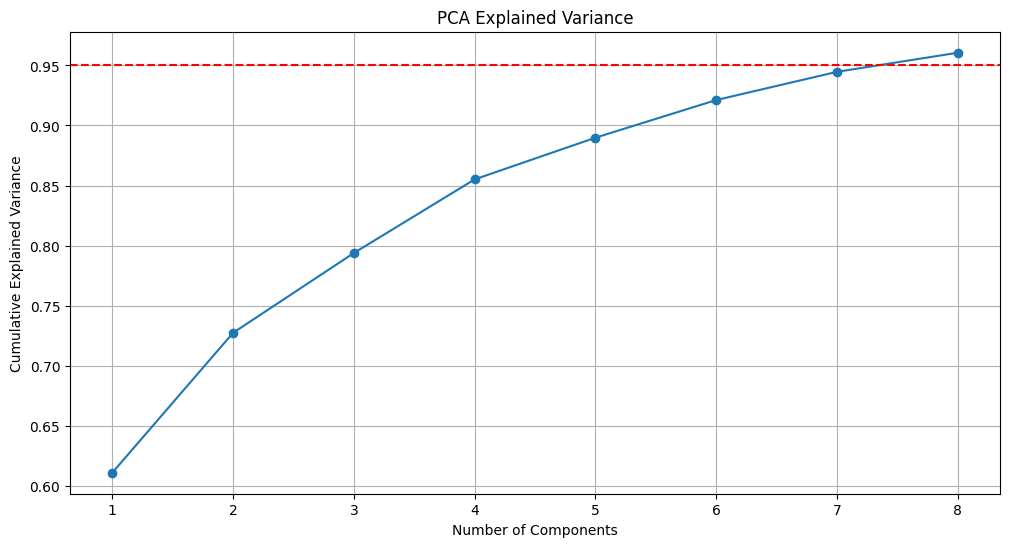


Feature importance from PCA loadings:
                   Sum_Abs
DFA               1.368727
spread2           1.306615
RPDE              1.262111
D2                1.208085
MDVP:Flo(Hz)      1.162582
MDVP:Fhi(Hz)      1.005141
MDVP:Fo(Hz)       0.992148
MDVP:Jitter(Abs)  0.864508
Jitter:DDP        0.846898
MDVP:RAP          0.846784

6. Model Performance with Different Feature Sets
         Feature Set  Accuracy  F1-Score  Precision    Recall  Best C
0    Linear SVM Coef  0.897436  0.890443   0.891704  0.897436     100
1       RFE with SVM  0.923077  0.914310   0.929670  0.923077     100
2  L1 Regularization  0.923077  0.914310   0.929670  0.923077       1
3      ANOVA F-value  0.948718  0.945221   0.951735  0.948718     100
4                PCA  0.948718  0.945221   0.951735  0.948718      10


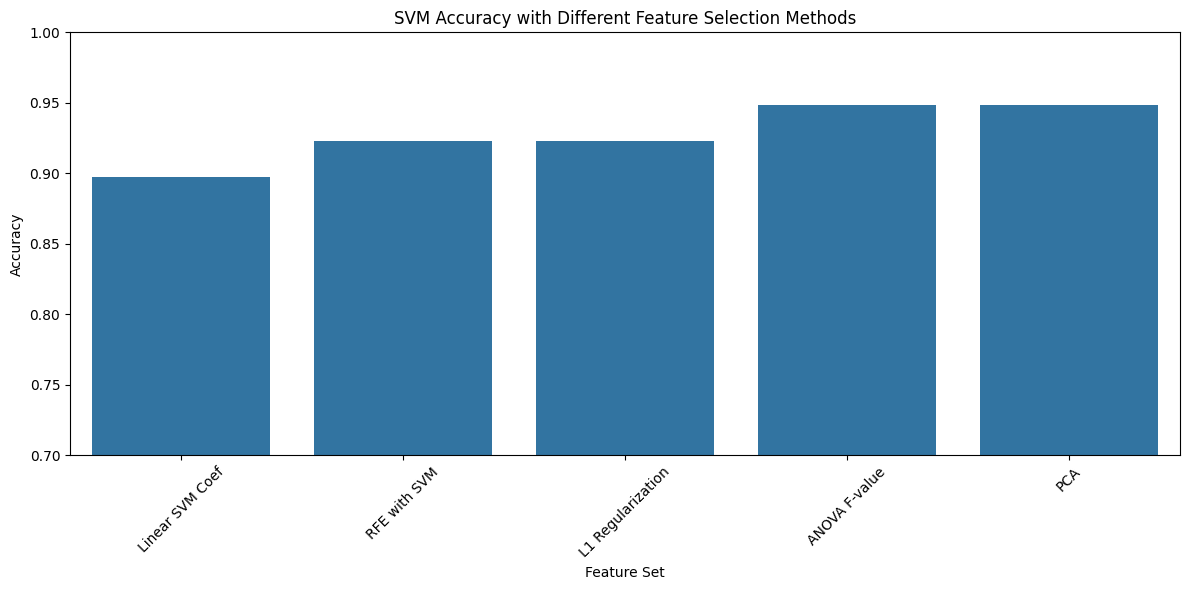


7. Common Features Across Methods
             Feature  Count
0                PPE      3
1           MDVP:APQ      3
13       MDVP:Fo(Hz)      3
2         Jitter:DDP      2
9   MDVP:Jitter(Abs)      2
3                 D2      2
14       Shimmer:DDA      2
16           spread1      2
12    MDVP:Jitter(%)      2
6           MDVP:RAP      2
8                HNR      1
7       Shimmer:APQ3      1
4           MDVP:PPQ      1
5       MDVP:Flo(Hz)      1
10      MDVP:Shimmer      1
11           spread2      1
15      Shimmer:APQ5      1
17  MDVP:Shimmer(dB)      1


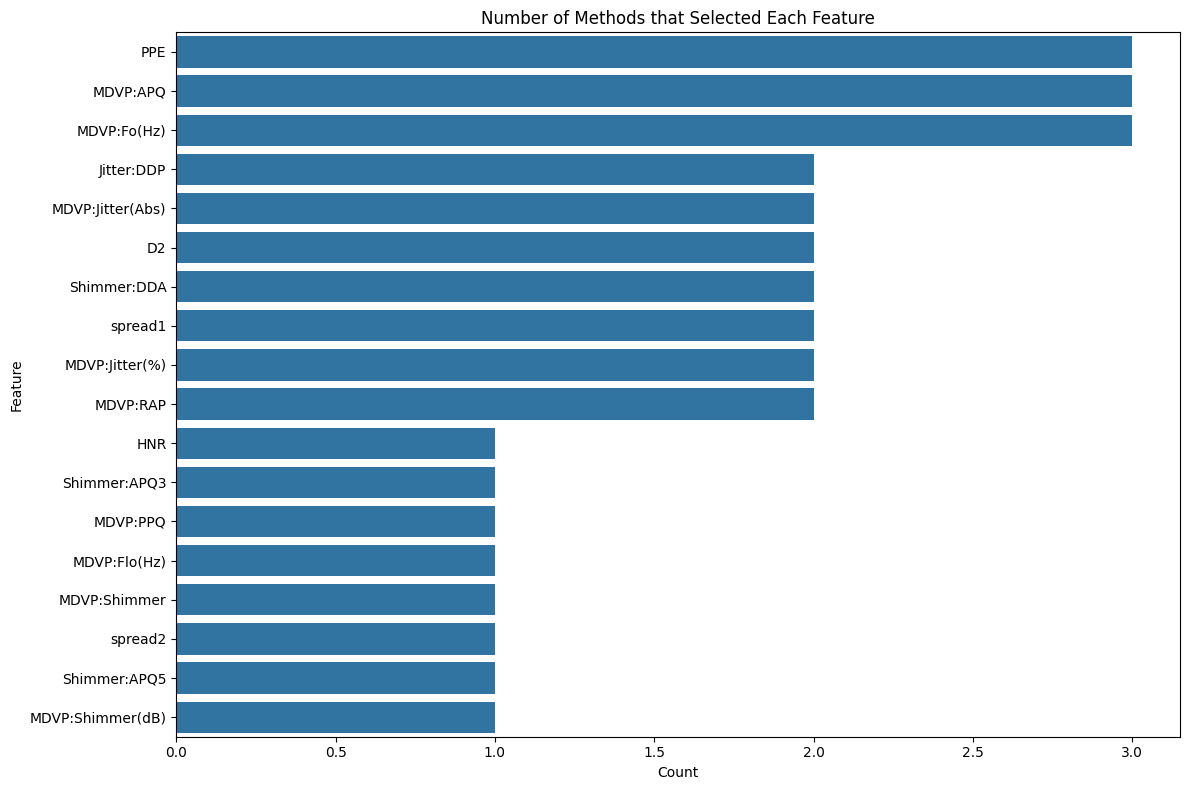


8. Recommended Final Feature Set
Recommended features (selected by at least 3 methods): ['PPE', 'MDVP:APQ', 'MDVP:Fo(Hz)']
Performance with recommended features: Accuracy = 0.8718, F1-Score = 0.8572

9. Finding Optimal Number of Features
Best feature selection method: ANOVA F-value
    Number of Features  Accuracy  F1-Score
0                    2  0.897436  0.879940
1                    3  0.897436  0.879940
2                    4  0.897436  0.890443
3                    5  0.923077  0.920710
4                    6  0.923077  0.920710
5                    7  0.948718  0.945221
6                    8  0.948718  0.945221
7                    9  0.948718  0.945221
8                   10  0.948718  0.945221
9                   11  0.948718  0.945221
10                  12  0.923077  0.914310
11                  13  0.923077  0.914310
12                  14  0.923077  0.914310
13                  15  0.923077  0.914310


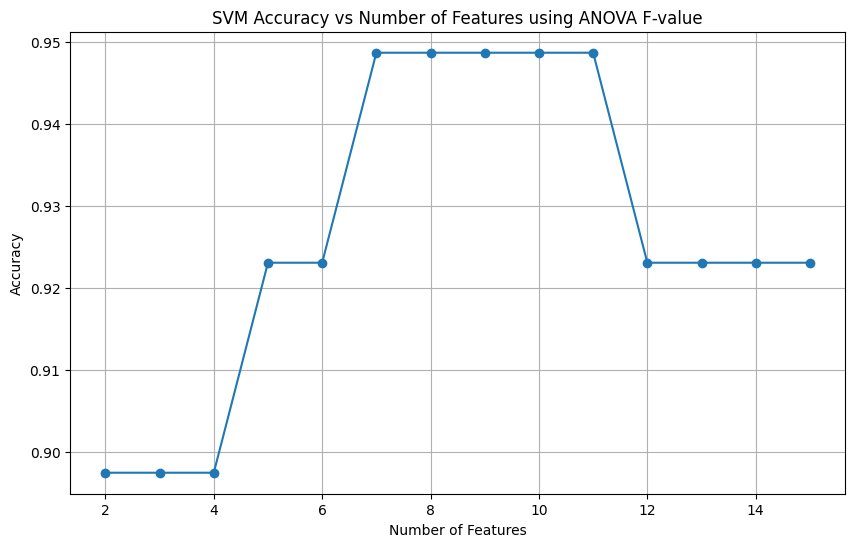


Optimal number of features: 7.0 with accuracy: 0.9487

10. Final SVM Model with Optimal Feature Set
Final selected features: ['HNR', 'MDVP:Flo(Hz)', 'MDVP:Fo(Hz)', 'MDVP:Shimmer', 'PPE', 'spread1', 'spread2']
Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Final SVM model accuracy: 0.9487

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.94      1.00      0.97        32

    accuracy                           0.95        39
   macro avg       0.97      0.86      0.90        39
weighted avg       0.95      0.95      0.95        39



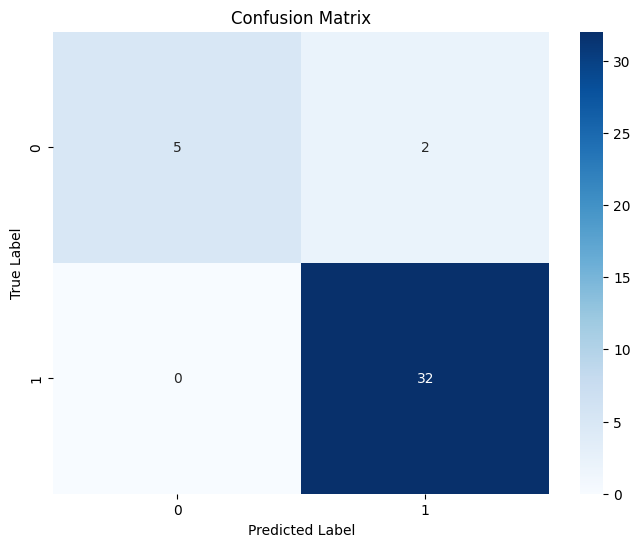

In [ ]:
# 1. Linear SVM Coefficients (for linear kernels)
print("1. Linear SVM Coefficients")
lsvc = LinearSVC(C=1.0, penalty="l2", dual=False, max_iter=5000, random_state=42)
lsvc.fit(X_train_scaled, y_train)
svm_coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': np.abs(lsvc.coef_[0])  # Using absolute values
})
svm_coefficients = svm_coefficients.sort_values('Coefficient', ascending=False)
print(svm_coefficients.head(10))

# Plot top 10 features based on SVM Coefficients
plt.figure(figsize=(12, 6))
sns.barplot(x='Coefficient', y='Feature', data=svm_coefficients.head(10))
plt.title('Top 10 Features based on Linear SVM Coefficients')
plt.tight_layout()
plt.show()

# 2. Recursive Feature Elimination with SVM
print("\n2. Recursive Feature Elimination with SVM")
svm_rfe = LinearSVC(C=1.0, max_iter=5000, random_state=42)
rfe = RFE(estimator=svm_rfe, n_features_to_select=10, step=1)
rfe.fit(X_train_scaled, y_train)
selected_features_rfe = feature_cols[rfe.support_]

# Create a dataframe with RFE rankings
rfe_ranks = pd.DataFrame({
    'Feature': feature_cols,
    'Ranking': rfe.ranking_
})
rfe_ranks = rfe_ranks.sort_values('Ranking')
print(rfe_ranks.head(10))

# 3. SelectFromModel with L1 penalty (Lasso)
print("\n3. L1-based Feature Selection")
lsvc_l1 = LinearSVC(C=0.01, penalty="l1", dual=False, max_iter=5000, random_state=42)
# Use SelectFromModel to select features based on L1 regularization
model_l1 = SelectFromModel(lsvc_l1)
model_l1.fit(X_train_scaled, y_train)
selected_features_l1 = feature_cols[model_l1.get_support()]

# Create a DataFrame showing selected features
l1_selected = pd.DataFrame({
    'Feature': feature_cols,
    'Selected': model_l1.get_support().astype(int)
})
l1_selected = l1_selected.sort_values('Selected', ascending=False)
print(l1_selected[l1_selected['Selected'] == 1])

# 4. Univariate Selection (ANOVA F-value)
print("\n4. Univariate Feature Selection with ANOVA F-value")
selector_f = SelectKBest(f_classif, k=10)
X_kbest_f = selector_f.fit_transform(X_train_scaled, y_train)
selected_features_f = feature_cols[selector_f.get_support()]

# Get scores and p-values for all features
f_scores = pd.DataFrame({
    'Feature': feature_cols,
    'F-Score': selector_f.scores_,
    'P-value': selector_f.pvalues_
})
f_scores = f_scores.sort_values('F-Score', ascending=False)
print(f_scores.head(10))

# 5. Principal Component Analysis (PCA)
print("\n5. Principal Component Analysis (PCA)")
pca = PCA(n_components=0.95)  # Keep components that explain 95% of variance
pca.fit(X_train_scaled)

# Print variance explained by each component
explained_variance = pd.DataFrame({
    'Component': range(1, len(pca.explained_variance_ratio_) + 1),
    'Explained Variance': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca.explained_variance_ratio_)
})
print(f"Number of components selected: {pca.n_components_}")
print(explained_variance.head(10))

# Plot PCA explained variance
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.show()

# Feature importance from PCA loadings
# Get the loading scores for the first few principal components
n_components_to_show = min(5, pca.n_components_)
loading_scores = pd.DataFrame(
    data=pca.components_[:n_components_to_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_to_show)],
    index=feature_cols
)
loading_scores['Sum_Abs'] = loading_scores.abs().sum(axis=1)
loading_scores = loading_scores.sort_values('Sum_Abs', ascending=False)
print("\nFeature importance from PCA loadings:")
print(loading_scores.head(10)[['Sum_Abs']])

# 6. Evaluate SVM with different feature sets
print("\n6. Model Performance with Different Feature Sets")

def evaluate_feature_set(X_train, X_test, y_train, y_test, feature_set, name):
    if len(feature_set) == 0:
        return {
            'Feature Set': name,
            'Accuracy': 0,
            'F1-Score': 0,
            'Precision': 0,
            'Recall': 0
        }

    X_train_selected = X_train[:, feature_set]
    X_test_selected = X_test[:, feature_set]

    # Simple grid search for C parameter in SVM
    param_grid = {'C': [0.1, 1, 10, 100]}
    grid = GridSearchCV(SVC(kernel='rbf', gamma='scale', random_state=42),
                        param_grid, cv=5, scoring='accuracy')
    grid.fit(X_train_selected, y_train)

    best_svm = grid.best_estimator_
    y_pred = best_svm.predict(X_test_selected)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)

    return {
        'Feature Set': name,
        'Accuracy': accuracy,
        'F1-Score': report['weighted avg']['f1-score'],
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'Best C': grid.best_params_['C']
    }

# Get indices of selected features
svm_coef_indices = [list(feature_cols).index(feature) for feature in svm_coefficients['Feature'].head(10)]
rfe_indices = np.where(rfe.support_)[0]
l1_indices = np.where(model_l1.get_support())[0]
f_value_indices = np.where(selector_f.get_support())[0]

# Evaluate SVM with different feature sets
results = []
results.append(evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, svm_coef_indices, 'Linear SVM Coef'))
results.append(evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, rfe_indices, 'RFE with SVM'))
results.append(evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, l1_indices, 'L1 Regularization'))
results.append(evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, f_value_indices, 'ANOVA F-value'))

# Evaluate PCA transformed data
pca_transform = PCA(n_components=pca.n_components_)
X_train_pca = pca_transform.fit_transform(X_train_scaled)
X_test_pca = pca_transform.transform(X_test_scaled)

# Grid search for PCA
param_grid = {'C': [0.1, 1, 10, 100]}
grid_pca = GridSearchCV(SVC(kernel='rbf', gamma='scale', random_state=42),
                    param_grid, cv=5, scoring='accuracy')
grid_pca.fit(X_train_pca, y_train)
best_svm_pca = grid_pca.best_estimator_
y_pred_pca = best_svm_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test, y_pred_pca)
report_pca = classification_report(y_test, y_pred_pca, output_dict=True)

results.append({
    'Feature Set': 'PCA',
    'Accuracy': accuracy_pca,
    'F1-Score': report_pca['weighted avg']['f1-score'],
    'Precision': report_pca['weighted avg']['precision'],
    'Recall': report_pca['weighted avg']['recall'],
    'Best C': grid_pca.best_params_['C']
})

# Compare results
results_df = pd.DataFrame(results)
print(results_df)

# Plot comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature Set', y='Accuracy', data=results_df)
plt.title('SVM Accuracy with Different Feature Selection Methods')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. Find common features across methods
print("\n7. Common Features Across Methods")
all_selected_features = set()
all_selected_features.update(
    svm_coefficients['Feature'].head(10),
    selected_features_rfe,
    selected_features_l1,
    selected_features_f
)

feature_count = {}
for feature in all_selected_features:
    count = 0
    if feature in svm_coefficients['Feature'].head(10).values: count += 1
    if feature in selected_features_rfe: count += 1
    if feature in selected_features_l1: count += 1
    if feature in selected_features_f: count += 1
    feature_count[feature] = count

feature_count_df = pd.DataFrame({
    'Feature': list(feature_count.keys()),
    'Count': list(feature_count.values())
}).sort_values('Count', ascending=False)

print(feature_count_df)

# Plot feature counts
plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Feature', data=feature_count_df)
plt.title('Number of Methods that Selected Each Feature')
plt.tight_layout()
plt.show()

# 8. Recommend the final feature set based on best performance
print("\n8. Recommended Final Feature Set")

# Features selected by at least 3 methods
recommended_features = feature_count_df[feature_count_df['Count'] >= 3]['Feature'].tolist()
print(f"Recommended features (selected by at least 3 methods): {recommended_features}")

# Evaluate the recommended feature set
if recommended_features:
    recommended_indices = [list(feature_cols).index(feature) for feature in recommended_features]
    recommended_results = evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, recommended_indices, 'Recommended')
    print(f"Performance with recommended features: Accuracy = {recommended_results['Accuracy']:.4f}, F1-Score = {recommended_results['F1-Score']:.4f}")

# 9. Find optimal number of features using the best method
print("\n9. Finding Optimal Number of Features")
# Use the best method based on previous results to find optimal number of features
best_method = results_df.loc[results_df['Accuracy'].idxmax()]['Feature Set']
print(f"Best feature selection method: {best_method}")

# Evaluate different feature counts (from 2 to 15)
feature_count_results = []
for k in range(2, 16):
    if best_method == 'Linear SVM Coef':
        indices = [list(feature_cols).index(feature) for feature in svm_coefficients['Feature'].head(k)]
    elif best_method == 'RFE with SVM':
        selector = RFE(estimator=svm_rfe, n_features_to_select=k, step=1)
        selector.fit(X_train_scaled, y_train)
        indices = np.where(selector.support_)[0]
    elif best_method == 'L1 Regularization':
        # For L1, we need to adjust C to control the number of features
        # This is an approximation
        c_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
        found_k = False
        for c in c_values:
            lsvc_l1_k = LinearSVC(C=c, penalty="l1", dual=False, max_iter=10000, random_state=42)
            model_l1_k = SelectFromModel(lsvc_l1_k)
            model_l1_k.fit(X_train_scaled, y_train)
            if sum(model_l1_k.get_support()) == k:
                indices = np.where(model_l1_k.get_support())[0]
                found_k = True
                break
        if not found_k:
            continue  # Skip this k if we can't get exactly k features
    elif best_method == 'ANOVA F-value':
        selector = SelectKBest(f_classif, k=k)
        selector.fit(X_train_scaled, y_train)
        indices = np.where(selector.get_support())[0]
    elif best_method == 'PCA':
        # For PCA, we'll use the first k components
        pca_k = PCA(n_components=k)
        X_train_pca_k = pca_k.fit_transform(X_train_scaled)
        X_test_pca_k = pca_k.transform(X_test_scaled)
        # Grid search for PCA
        param_grid = {'C': [0.1, 1, 10, 100]}
        grid_pca_k = GridSearchCV(SVC(kernel='rbf', gamma='scale', random_state=42),
                            param_grid, cv=5, scoring='accuracy')
        grid_pca_k.fit(X_train_pca_k, y_train)
        best_svm_pca_k = grid_pca_k.best_estimator_
        y_pred_pca_k = best_svm_pca_k.predict(X_test_pca_k)
        accuracy_pca_k = accuracy_score(y_test, y_pred_pca_k)
        report_pca_k = classification_report(y_test, y_pred_pca_k, output_dict=True)
        feature_count_results.append({
            'Number of Features': k,
            'Accuracy': accuracy_pca_k,
            'F1-Score': report_pca_k['weighted avg']['f1-score']
        })
        continue

    # Evaluate SVM with k features
    result = evaluate_feature_set(X_train_scaled, X_test_scaled, y_train, y_test, indices, f"{best_method} (k={k})")
    feature_count_results.append({
        'Number of Features': k,
        'Accuracy': result['Accuracy'],
        'F1-Score': result['F1-Score']
    })

# Display results for different feature counts
feature_count_df = pd.DataFrame(feature_count_results)
print(feature_count_df)

# Plot accuracy vs number of features
plt.figure(figsize=(10, 6))
plt.plot(feature_count_df['Number of Features'], feature_count_df['Accuracy'], marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title(f'SVM Accuracy vs Number of Features using {best_method}')
plt.grid(True)
plt.show()

# Find optimal number of features
optimal_k = feature_count_df.loc[feature_count_df['Accuracy'].idxmax()]['Number of Features']
max_accuracy = feature_count_df['Accuracy'].max()
print(f"\nOptimal number of features: {optimal_k} with accuracy: {max_accuracy:.4f}")

# 10. Final SVM model with optimal features
print("\n10. Final SVM Model with Optimal Feature Set")

# Get optimal feature set
if best_method == 'Linear SVM Coef':
    optimal_features = svm_coefficients['Feature'].head(int(optimal_k)).tolist()
elif best_method == 'RFE with SVM':
    selector = RFE(estimator=svm_rfe, n_features_to_select=int(optimal_k), step=1)
    selector.fit(X_train_scaled, y_train)
    optimal_features = feature_cols[selector.support_].tolist()
elif best_method == 'L1 Regularization':
    # Use the L1 model that gave us closest to optimal_k features
    c_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10]
    best_c = None
    best_diff = float('inf')
    best_support = None

    for c in c_values:
        lsvc_l1_opt = LinearSVC(C=c, penalty="l1", dual=False, max_iter=10000, random_state=42)
        model_l1_opt = SelectFromModel(lsvc_l1_opt)
        model_l1_opt.fit(X_train_scaled, y_train)
        n_features = sum(model_l1_opt.get_support())
        diff = abs(n_features - optimal_k)
        if diff < best_diff:
            best_diff = diff
            best_c = c
            best_support = model_l1_opt.get_support()

    optimal_features = feature_cols[best_support].tolist()
    print(f"Best C for L1: {best_c}, Selected {len(optimal_features)} features")
elif best_method == 'ANOVA F-value':
    selector = SelectKBest(f_classif, k=int(optimal_k))
    selector.fit(X_train_scaled, y_train)
    optimal_features = feature_cols[selector.get_support()].tolist()
else:  # PCA
    optimal_features = [f"PC{i+1}" for i in range(int(optimal_k))]
    print("Using PCA components as features")

print(f"Final selected features: {optimal_features}")

# If using PCA, we need to transform the data
if best_method == 'PCA':
    pca_final = PCA(n_components=int(optimal_k))
    X_train_final = pca_final.fit_transform(X_train_scaled)
    X_test_final = pca_final.transform(X_test_scaled)
else:
    # Get indices of optimal features
    optimal_indices = [list(feature_cols).index(feature) for feature in optimal_features]
    X_train_final = X_train_scaled[:, optimal_indices]
    X_test_final = X_test_scaled[:, optimal_indices]

# Train final SVM model with grid search for hyperparameters
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']
}

grid_final = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_final.fit(X_train_final, y_train)

# Best parameters and performance
print(f"Best parameters: {grid_final.best_params_}")
best_svm_final = grid_final.best_estimator_
y_pred_final = best_svm_final.predict(X_test_final)
accuracy_final = accuracy_score(y_test, y_pred_final)
print(f"Final SVM model accuracy: {accuracy_final:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pickle
import os

In [ ]:
# Create a directory for the model
os.makedirs('/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model', exist_ok=True)

# Save the scaler
with open('/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Define which feature selection method you're using
# In this case, based on the notebook's final selection:
feature_indices = [list(feature_cols).index(feature) for feature in
                   ['HNR', 'MDVP:Flo(Hz)', 'MDVP:Fo(Hz)', 'MDVP:Shimmer', 'PPE', 'spread1', 'spread2']]

# Save the feature names and indices
with open('/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/selected_features.pkl', 'wb') as f:
    pickle.dump({
        'names': ['HNR', 'MDVP:Flo(Hz)', 'MDVP:Fo(Hz)', 'MDVP:Shimmer', 'PPE', 'spread1', 'spread2'],
        'indices': feature_indices
    }, f)

# Save the final SVM model
with open('/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/svm_model.pkl', 'wb') as f:
    pickle.dump(best_svm_final, f)

print("Model and preprocessing components saved successfully!")

Model and preprocessing components saved successfully!


In [ ]:
!pip install praat-parselmouth

In [ ]:
import os
import pickle
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
from IPython.display import display, HTML, Audio
import io
import warnings
warnings.filterwarnings('ignore')
import parselmouth
from parselmouth.praat import call

In [ ]:
class ParkinsonsDetection:
    """Parkinson's Disease Detection from Voice"""

    def __init__(self):
        """Initialize the detection system"""
        self.load_model()
        print("✅ Model loaded successfully")

    def load_model(self):
        """Load the saved model components"""
        model_dir = 'parkinsons_model'

        # Load the model components
        with open(os.path.join(model_dir, '/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/scaler.pkl'), 'rb') as f:
            self.scaler = pickle.load(f)
        with open(os.path.join(model_dir, '/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/selected_features.pkl'), 'rb') as f:
            self.selected_features = pickle.load(f)
        with open(os.path.join(model_dir, '/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model/svm_model.pkl'), 'rb') as f:
            self.model = pickle.load(f)

    def extract_features(self, audio_path):
        """Extract relevant voice features from audio recording"""
        print("📊 Extracting voice features...")
        # Load the audio file
        y, sr = librosa.load(audio_path, sr=None)
        # Create a Praat Sound object
        sound = parselmouth.Sound(y, sr)
        # Extract pitch features
        pitch = call(sound, "To Pitch", 0.0, 75, 600)
        # Get basic pitch statistics
        f0_mean = call(pitch, "Get mean", 0, 0, "Hertz")  # MDVP:Fo(Hz)
        f0_min = call(pitch, "Get minimum", 0, 0, "Hertz", "Parabolic")  # MDVP:Flo(Hz)
        # Extract harmonicity (HNR)
        harmonicity = call(sound, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)  # HNR
        # Extract shimmer
        point_process = call(sound, "To PointProcess (periodic, cc)", 75, 600)
        shimmer = call([sound, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)  # MDVP:Shimmer
        # For PPE, spread1, and spread2
        pitch_values = np.array(pitch.selected_array['frequency'])
        pitch_values = pitch_values[pitch_values != 0]
        jitter = np.mean(np.abs(np.diff(pitch_values))) / np.mean(pitch_values) if len(pitch_values) > 1 else 0
        if len(pitch_values) > 2:
            spread1 = np.std(np.diff(pitch_values))
            spread2 = np.std(np.diff(np.diff(pitch_values)))
        else:
            spread1 = spread2 = 0
        if len(pitch_values) > 1:
            normalized = (pitch_values - np.mean(pitch_values)) / np.std(pitch_values)
            ppe = np.log(np.sum(normalized**2) / len(normalized))
        else:
            ppe = 0
        features = {
            'MDVP:Fo(Hz)': f0_mean,
            'MDVP:Flo(Hz)': f0_min,
            'HNR': hnr,
            'MDVP:Shimmer': shimmer,
            'PPE': ppe,
            'spread1': spread1,
            'spread2': spread2,
            'jitter': jitter
        }
        return features

    def predict_parkinsons(self, features):
        """Predict if features indicate Parkinson's disease"""
        print("🔄 Making prediction...")
        vec = np.array([features[name] for name in self.selected_features['names']]).reshape(1, -1)
        scaled = self.scaler.transform(vec)
        pred = self.model.predict(scaled)[0]
        if hasattr(self.model, 'predict_proba'):
            prob = self.model.predict_proba(scaled)[0][1]
        else:
            decision = self.model.decision_function(scaled)[0]
            prob = 1 / (1 + np.exp(-decision))
        result_text = "Parkinson's detected" if pred == 1 else "Healthy"
        confidence = prob if pred == 1 else 1 - prob
        return {'prediction': int(pred), 'result': result_text, 'confidence': float(confidence)}

    def display_waveform(self, y, sr):
        plt.figure(figsize=(10, 4))
        time = np.arange(len(y)) / sr
        plt.plot(time, y)
        plt.title("Audio Waveform")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.tight_layout()
        plt.show()
        display(Audio(y, rate=sr))

    def display_features(self, features):
        df = pd.DataFrame({'Feature': list(features.keys()), 'Value': list(features.values())})
        display(df)

    def display_results(self, result, features):
        color = "red" if result['prediction'] == 1 else "green"
        text = f"⚠️ Parkinson's Disease Detected (Confidence: {result['confidence']:.1%})" if result['prediction'] == 1 else f"✅ No Parkinson's Disease Detected (Confidence: {result['confidence']:.1%})"
        display(HTML(f"<h3 style='color:{color};'>{text}</h3>"))
        self.display_features(features)
        plt.figure(figsize=(12, 6))
        plt.bar(list(features.keys()), list(features.values()))
        plt.xticks(rotation=45)
        plt.title("Feature Values")
        plt.tight_layout()
        plt.show()


def upload_model_files():
    """Upload the model files to Google Colab"""
    print("Please upload model files: scaler.pkl, selected_features.pkl, svm_model.pkl")
    uploaded = files.upload()
    model_dir = 'parkinsons_model'
    os.makedirs(model_dir, exist_ok=True)
    for key, content in uploaded.items():
        dest = os.path.join(model_dir, key)
        with open(dest, 'wb') as f:
            f.write(content)
    print("✅ Model files uploaded successfully")


def run_parkinsons_detection():
    """Main function to run detection in Colab"""
    # Ensure model files exist
    model_dir = '/content/drive/MyDrive/OLYMPAD/Detection model/parkinsons_model'
    required = {'scaler.pkl', 'selected_features.pkl', 'svm_model.pkl'}
    if not os.path.isdir(model_dir) or not required.issubset(set(os.listdir(model_dir))):
        upload_model_files()
    # Initialize detector
    detector = ParkinsonsDetection()
    # Upload audio file
    print("Please upload an audio file (.wav, .mp3, or .ogg):")
    audio_upload = files.upload()
    for fname in audio_upload:
        path = fname
        with open(path, 'wb') as f:
            f.write(audio_upload[fname])
        y, sr = librosa.load(path, sr=None)
        detector.display_waveform(y, sr)
        features = detector.extract_features(path)
        result = detector.predict_parkinsons(features)
        detector.display_results(result, features)
        os.remove(path)


✅ Model loaded successfully
Please upload an audio file (.wav, .mp3, or .ogg):


Saving Recording (107).m4a to Recording (107) (2).m4a


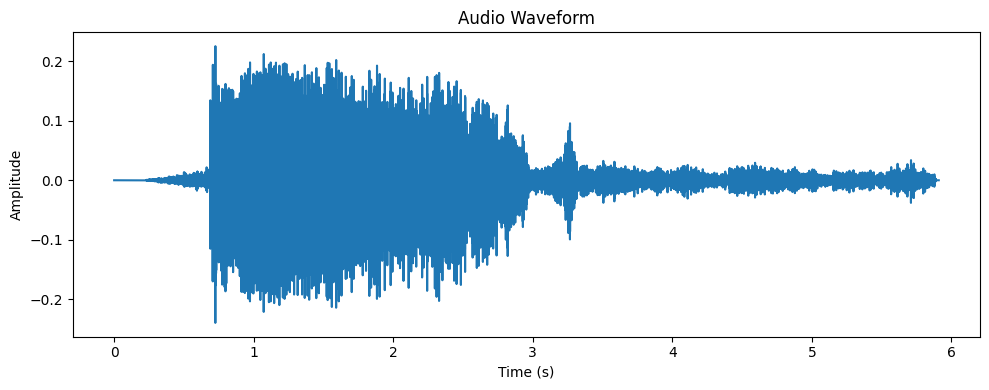

📊 Extracting voice features...
🔄 Making prediction...


,Feature,Value
0,MDVP:Fo(Hz),1.384886e+02
1,MDVP:Flo(Hz),7.586117e+01
2,HNR,5.735810e+00
3,MDVP:Shimmer,1.736756e-01
4,PPE,-2.220446e-16
5,spread1,7.532622e+01
6,spread2,1.075901e+02
7,jitter,1.288534e-01


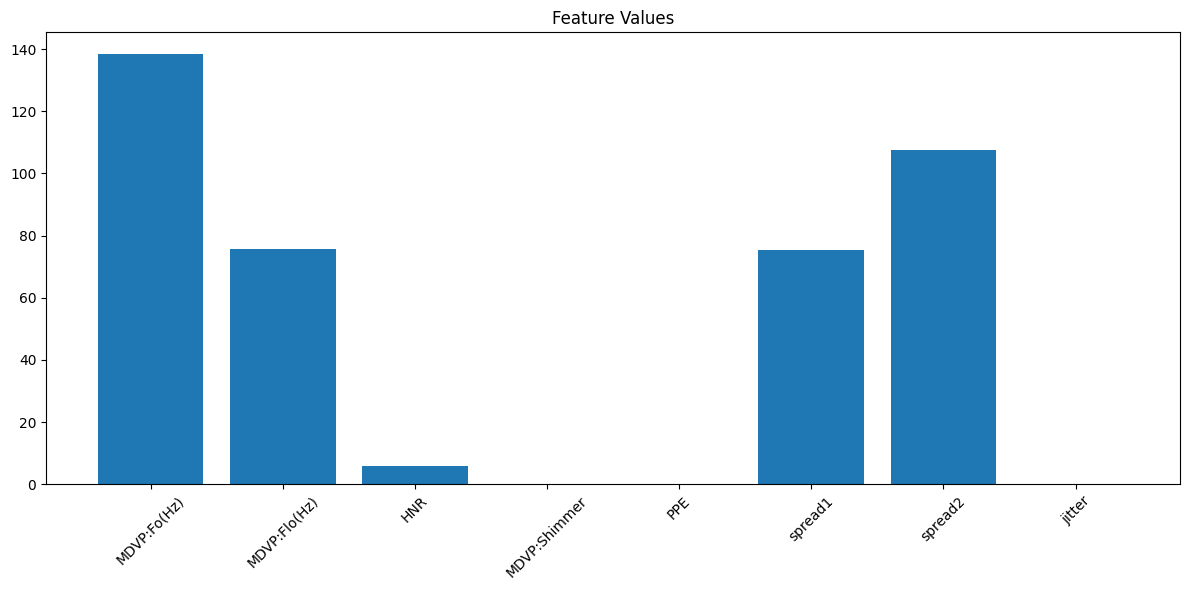

In [ ]:
# Execute
run_parkinsons_detection()